# **TikTok Project**
**Course 4 - Regression Analysis: Simplify complex data relationships**

In [1]:
import numpy as np
import pandas as pd
import platform
import statsmodels
print('Python version: ', platform.python_version())
print('numpy version: ', np.__version__)
print('pandas version: ', pd.__version__)
print('statsmodels version: ', statsmodels.__version__)

Python version:  3.11.4
numpy version:  1.24.4
pandas version:  2.0.3
statsmodels version:  0.14.0


You are a data professional at TikTok. The data team is working towards building a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

The team is getting closer to completing the project, having completed an initial plan of action, initial Python coding work, EDA, and hypothesis testing.

The TikTok team has reviewed the results of the hypothesis testing. TikTok’s Operations Lead, Maika Abadi, is interested in how different variables are associated with whether a user is verified. Earlier, the data team observed that if a user is verified, they are much more likely to post opinions. Now, the data team has decided to explore how to predict verified status to help them understand how video characteristics relate to verified users. Therefore, you have been asked to conduct a logistic regression using verified status as the outcome variable. The results may be used to inform the final model related to predicting whether a video is a claim vs an opinion.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 4 End-of-course project: Regression modeling**


In this activity, you will build a logistic regression model in Python. As you have learned, logistic regression helps you estimate the probability of an outcome. For data science professionals, this is a useful skill because it allows you to consider more than one variable against the variable you're measuring against. This opens the door for much more thorough and flexible analysis to be completed.

<br/>

**The purpose** of this project is to demostrate knowledge of EDA and regression models.

**The goal** is to build a logistic regression model and evaluate the model.
<br/>
*This activity has three parts:*

**Part 1:** EDA & Checking Model Assumptions
* What are some purposes of EDA before constructing a logistic regression model?

**Part 2:** Model Building and Evaluation
* What resources do you find yourself using as you complete this stage?

**Part 3:** Interpreting Model Results

* What key insights emerged from your model(s)?

* What business recommendations do you propose based on the models built?

Follow the instructions and answer the question below to complete the activity. Then, you will complete an executive summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.


# **Build a regression model**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**
Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

### **Task 1. Imports and loading**
Import the data and packages that you've learned are needed for building regression models.

In [2]:
# Import packages for data manipulation
import numpy as np
import pandas as pd

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Import packages for data modeling
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


Load the TikTok dataset.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [4]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

In this stage, consider the following question where applicable to complete your code response:

* What are some purposes of EDA before constructing a logistic regression model?


EDA helps identify missing values, outliers, variable distributions, and relationships between predictors and the target variable before building a logistic regression model. It also helps improve data quality and model reliability.

### **Task 2a. Explore data with EDA**

Analyze the data and check for and handle missing values and duplicates.

Inspect the first five rows of the dataframe.

In [ ]:
# Display first few rows
### YOUR CODE HERE ###


Get the number of rows and columns in the dataset.

In [5]:
# Get number of rows and columns
data.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Get the data types of the columns.

In [6]:
# Get data types of columns
data.dtypes


#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

Get basic information about the dataset.

In [7]:
# Get basic information
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


Generate basic descriptive statistics about the dataset.

In [8]:
# Generate basic descriptive stats
data.describe()


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Check for and handle missing values.

In [9]:
# Check for missing values
data.isnull().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [10]:
# Drop rows with missing values
data = data.dropna()

In [11]:
# Display first few rows after handling missing values
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Check for and handle duplicates.

In [12]:
# Check for duplicates
data.duplicated().sum()

0

Check for and handle outliers.

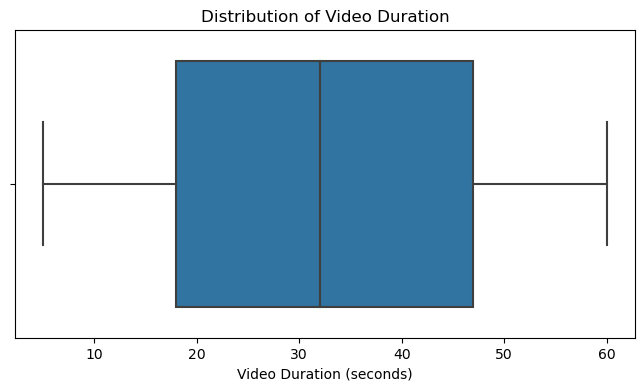

In [13]:
# Create a boxplot to visualize distribution of `video_duration_sec`
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['video_duration_sec'])

plt.title('Distribution of Video Duration')
plt.xlabel('Video Duration (seconds)')

plt.show()

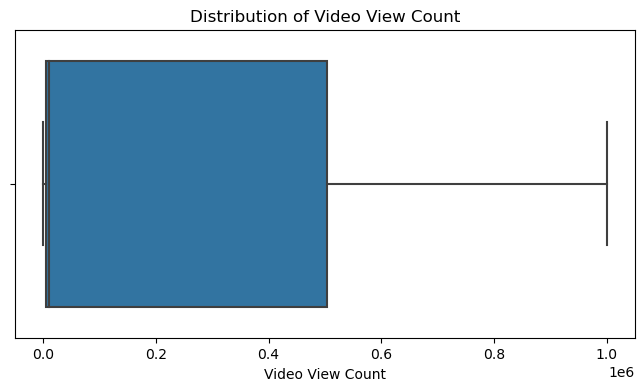

In [14]:
# Create a boxplot to visualize distribution of `video_view_count`
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['video_view_count'])

plt.title('Distribution of Video View Count')
plt.xlabel('Video View Count')

plt.show()



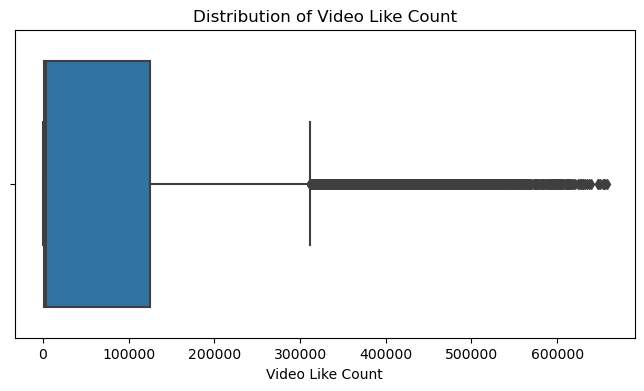

In [15]:
# Create a boxplot to visualize distribution of `video_like_count`
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['video_like_count'])

plt.title('Distribution of Video Like Count')
plt.xlabel('Video Like Count')

plt.show()

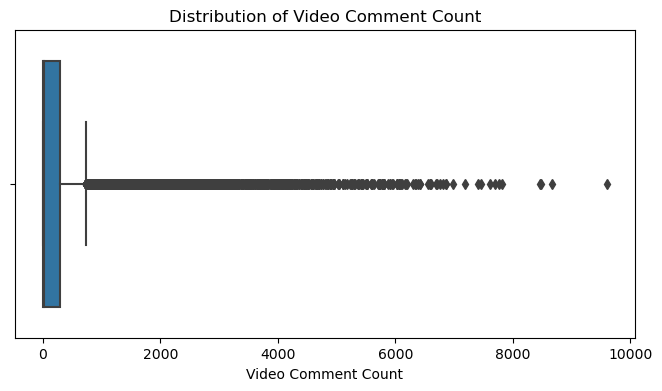

In [16]:
# Create a boxplot to visualize distribution of `video_comment_count`
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['video_comment_count'])

plt.title('Distribution of Video Comment Count')
plt.xlabel('Video Comment Count')

plt.show()



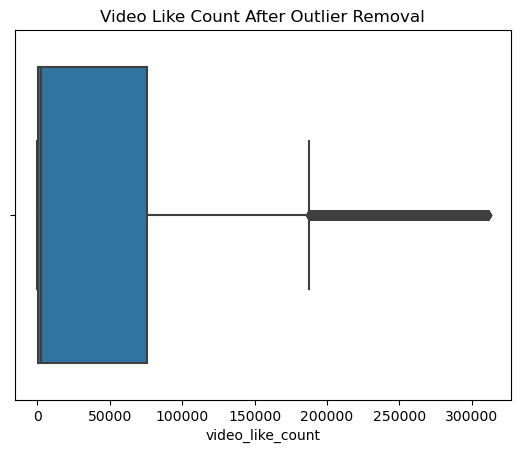

In [17]:
# Check for and handle outliers for video_like_count
Q1 = data['video_like_count'].quantile(0.25)
Q3 = data['video_like_count'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
data = data[
    (data['video_like_count'] >= lower_bound) &
    (data['video_like_count'] <= upper_bound)
]

# Verify updated distribution
sns.boxplot(x=data['video_like_count'])
plt.title('Video Like Count After Outlier Removal')
plt.show()


Check class balance of the target variable. Remember, the goal is to predict whether the user of a given post is verified or unverified.

In [18]:
# Check class balance
data['claim_status'].value_counts()

# Optional: percentage distribution
data['claim_status'].value_counts(normalize=True) * 100


claim_status
opinion    54.591543
claim      45.408457
Name: proportion, dtype: float64

Approximately 94.2% of the dataset represents videos posted by unverified accounts and 5.8% represents videos posted by verified accounts. So the outcome variable is not very balanced.

Use resampling to create class balance in the outcome variable, if needed.

In [19]:
# Use resampling to create class balance in the outcome variable, if needed
from sklearn.utils import resample

# Identify data points from majority and minority classes
majority = data[data['verified_status'] == 'not verified']
minority = data[data['verified_status'] == 'verified']

# Upsample the minority class, which is "verified"
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

# Combine majority class with upsampled minority class
data_balanced = pd.concat([majority, minority_upsampled])

# Display new class counts
data_balanced['verified_status'].value_counts()

verified_status
not verified    16200
verified        16200
Name: count, dtype: int64

Get the average `video_transcription_text` length for videos posted by verified accounts and the average `video_transcription_text` length for videos posted by unverified accounts.



In [20]:
# Get the average `video_transcription_text` length for claims and the average `video_transcription_text` length for opinions
data['text_length'] = data['video_transcription_text'].str.len()

# Get average text length for claims and opinions
data.groupby('claim_status')['text_length'].mean()


claim_status
claim      95.487693
opinion    82.722562
Name: text_length, dtype: float64

Extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [21]:
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe
data['text_length'] = data['video_transcription_text'].str.len()


In [22]:
# Display first few rows of dataframe after adding new column
data.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts.

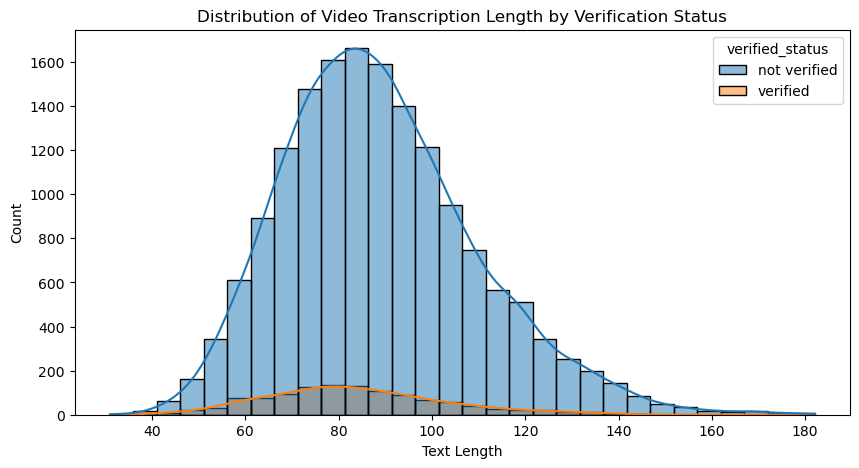

In [23]:
# Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts
# Create histograms for text length by verification status

plt.figure(figsize=(10, 5))

sns.histplot(
    data=data,
    x='text_length',
    hue='verified_status',
    bins=30,
    kde=True,
    multiple='layer'
)

plt.title('Distribution of Video Transcription Length by Verification Status')
plt.xlabel('Text Length')
plt.ylabel('Count')

plt.show()


### **Task 2b. Examine correlations**

Next, code a correlation matrix to help determine most correlated variables.

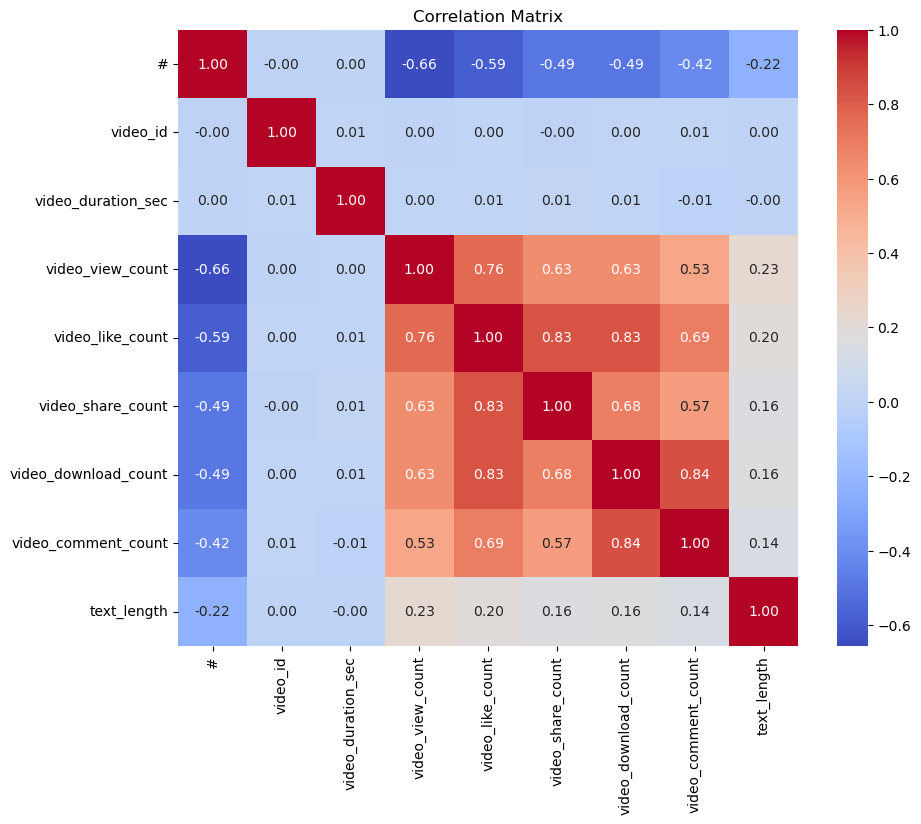

In [24]:
# Select numeric columns
numeric_cols = data.select_dtypes(include=np.number)

# Create correlation matrix
correlation_matrix = numeric_cols.corr()

# Display correlation matrix
correlation_matrix

# Optional: visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()


Visualize a correlation heatmap of the data.

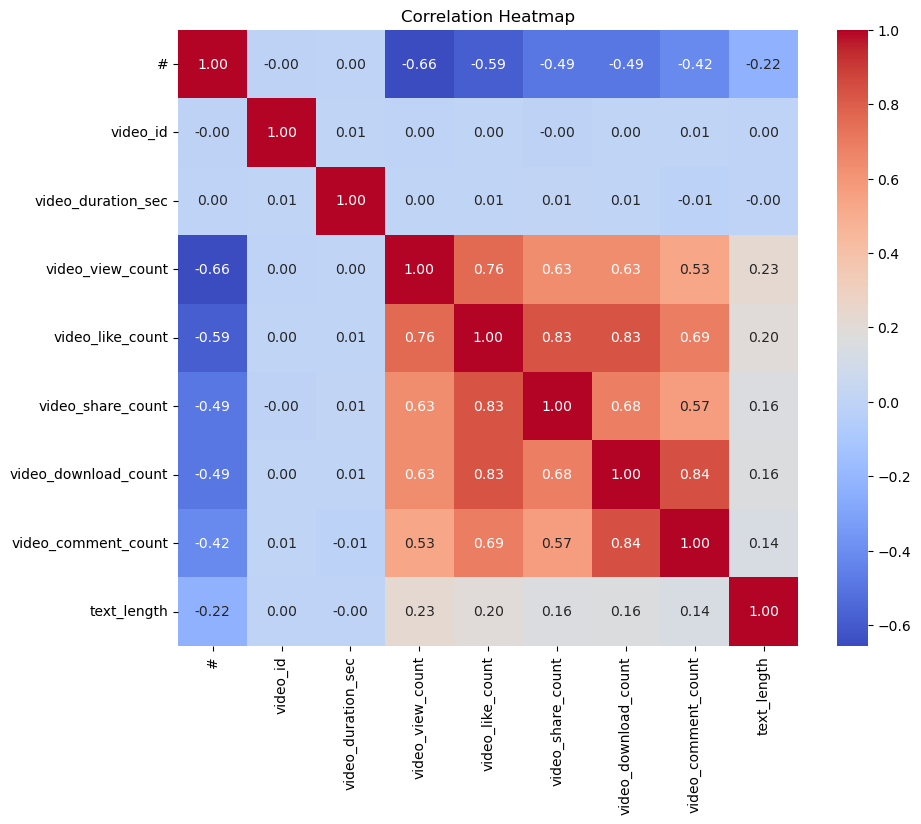

In [25]:
# Create a heatmap to visualize how correlated variables are

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()


One of the model assumptions for logistic regression is no severe multicollinearity among the features. Take this into consideration as you examine the heatmap and choose which features to proceed with.

**Question:** What variables are shown to be correlated in the heatmap?

<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**

After analysis and deriving variables with close relationships, it is time to begin constructing the model. Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3a. Select variables**

Set your Y and X variables.

Select the outcome variable.

In [26]:
# Select outcome variable
y = data['verified_status']


Select the features.

In [27]:
# Select features
X = data[[
    'video_duration_sec',
    'video_view_count',
    'video_like_count',
    'video_share_count',
    'video_download_count',
    'video_comment_count',
    'text_length'
]]

# Display first few rows of features dataframe
X.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,59,343296.0,19425.0,241.0,1.0,0.0,97
1,32,140877.0,77355.0,19034.0,1161.0,684.0,107
2,31,902185.0,97690.0,2858.0,833.0,329.0,137
3,25,437506.0,239954.0,34812.0,1234.0,584.0,131
4,19,56167.0,34987.0,4110.0,547.0,152.0,128


### **Task 3b. Train-test split**

Split the data into training and testing sets.

In [29]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Confirm that the dimensions of the training and testing sets are in alignment.

In [32]:
# Get shape of training and testing sets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



X_train shape: (13886, 7)
X_test shape: (3472, 7)
y_train shape: (13886,)
y_test shape: (3472,)


### **Task 3c. Encode variables**

Check the data types of the features.

In [33]:
# Check data types
print(X.dtypes)
print(y.dtypes)


video_duration_sec        int64
video_view_count        float64
video_like_count        float64
video_share_count       float64
video_download_count    float64
video_comment_count     float64
text_length               int64
dtype: object
object


In [34]:
# Get unique values in claim_status
data['claim_status'].unique()


array(['claim', 'opinion'], dtype=object)

In [35]:
# Get unique values in author_ban_status
data['author_ban_status'].unique()

array(['under review', 'active', 'banned'], dtype=object)

As shown above, the `claim_status` and `author_ban_status` features are each of data type `object` currently. In order to work with the implementations of models through `sklearn`, these categorical features will need to be made numeric. One way to do this is through one-hot encoding.

Encode categorical features in the training set using an appropriate method.

In [36]:
# Select the training features that need to be encoded
X_train_to_encode = X_train.select_dtypes(include=['object'])

# Display first few rows
X_train_to_encode.head()


""
4479
17712
7445
17663
12427


In [38]:
# Set up one-hot encoder
encoder = pd.get_dummies


In [39]:
# Fit and transform the training features using one-hot encoding
X_train_encoded = pd.get_dummies(X_train, drop_first=True)

# Display first few rows
X_train_encoded.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
4479,5,164368.0,84198.0,18289.0,1169.0,156.0,80
17712,37,7168.0,1570.0,274.0,10.0,0.0,69
7445,14,481707.0,271557.0,99112.0,5621.0,2888.0,92
17663,34,9511.0,3232.0,1266.0,54.0,11.0,110
12427,22,3810.0,1578.0,412.0,17.0,5.0,59


In [40]:
# Get feature names after encoding
X_train_encoded.columns


Index(['video_duration_sec', 'video_view_count', 'video_like_count',
       'video_share_count', 'video_download_count', 'video_comment_count',
       'text_length'],
      dtype='object')

In [41]:
# Display first few rows of encoded training features
X_train_encoded.head()


,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
4479,5,164368.0,84198.0,18289.0,1169.0,156.0,80
17712,37,7168.0,1570.0,274.0,10.0,0.0,69
7445,14,481707.0,271557.0,99112.0,5621.0,2888.0,92
17663,34,9511.0,3232.0,1266.0,54.0,11.0,110
12427,22,3810.0,1578.0,412.0,17.0,5.0,59


In [42]:
# Place encoded training features into a dataframe
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=X_train_encoded.columns,
    index=X_train.index
)

# Display first few rows
X_train_encoded_df.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
4479,5,164368.0,84198.0,18289.0,1169.0,156.0,80
17712,37,7168.0,1570.0,274.0,10.0,0.0,69
7445,14,481707.0,271557.0,99112.0,5621.0,2888.0,92
17663,34,9511.0,3232.0,1266.0,54.0,11.0,110
12427,22,3810.0,1578.0,412.0,17.0,5.0,59


In [44]:
# Display first few rows of X_train
X_train.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
4479,5,164368.0,84198.0,18289.0,1169.0,156.0,80
17712,37,7168.0,1570.0,274.0,10.0,0.0,69
7445,14,481707.0,271557.0,99112.0,5621.0,2888.0,92
17663,34,9511.0,3232.0,1266.0,54.0,11.0,110
12427,22,3810.0,1578.0,412.0,17.0,5.0,59


In [45]:
# Concatenate X_train and encoded dataframe to form final training dataframe
X_train_final = pd.concat(
    [
        X_train.reset_index(drop=True),
        X_train_encoded_df.reset_index(drop=True)
    ],
    axis=1
)

# Display first few rows
X_train_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,5,164368.0,84198.0,18289.0,1169.0,156.0,80,5,164368.0,84198.0,18289.0,1169.0,156.0,80
1,37,7168.0,1570.0,274.0,10.0,0.0,69,37,7168.0,1570.0,274.0,10.0,0.0,69
2,14,481707.0,271557.0,99112.0,5621.0,2888.0,92,14,481707.0,271557.0,99112.0,5621.0,2888.0,92
3,34,9511.0,3232.0,1266.0,54.0,11.0,110,34,9511.0,3232.0,1266.0,54.0,11.0,110
4,22,3810.0,1578.0,412.0,17.0,5.0,59,22,3810.0,1578.0,412.0,17.0,5.0,59


Check the data type of the outcome variable.

In [46]:
# Check data type of outcome variable
y_train.dtype

dtype('O')

In [47]:
# Get unique values of outcome variable
y_train.unique()

array(['not verified', 'verified'], dtype=object)

A shown above, the outcome variable is of data type `object` currently. One-hot encoding can be used to make this variable numeric.

Encode categorical values of the outcome variable the training set using an appropriate method.

In [48]:
# Set up label encoder for outcome variable
label_encoder = LabelEncoder()


In [49]:
# Encode the training outcome variable
y_train_encoded = label_encoder.fit_transform(y_train)

# Display encoded outcome variable
y_train_encoded


array([0, 0, 0, ..., 0, 0, 0])

### **Task 3d. Model building**

Construct a model and fit it to the training set.

In [50]:
# Construct logistic regression model
log_reg = LogisticRegression(max_iter=1000)

# Fit model to training data
log_reg.fit(X_train_final, y_train_encoded)


LogisticRegression(max_iter=1000)

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Taks 4a. Results and evaluation**

Evaluate your model.

Encode categorical features in the testing set using an appropriate method.

In [51]:
# Select testing features that need to be encoded
X_test_to_encode = X_test.select_dtypes(include=['object'])

# Display first few rows
X_test_to_encode.head()


""
16459
4297
6771
3411
6090


In [52]:
# Transform testing features using one-hot encoding
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Display first few rows of encoded testing features
X_test_encoded.head()


,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
16459,24,4870.0,98.0,14.0,1.0,0.0,79
4297,20,564768.0,145548.0,35358.0,267.0,39.0,85
6771,17,113742.0,47826.0,9056.0,744.0,474.0,87
3411,21,606621.0,299444.0,71135.0,3964.0,1948.0,86
6090,25,305755.0,176879.0,30620.0,630.0,53.0,120


In [53]:
# Place encoded testing features into a dataframe
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=X_test_encoded.columns,
    index=X_test.index
)

# Display first few rows
X_test_encoded_df.head()


,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
16459,24,4870.0,98.0,14.0,1.0,0.0,79
4297,20,564768.0,145548.0,35358.0,267.0,39.0,85
6771,17,113742.0,47826.0,9056.0,744.0,474.0,87
3411,21,606621.0,299444.0,71135.0,3964.0,1948.0,86
6090,25,305755.0,176879.0,30620.0,630.0,53.0,120


In [54]:
# Display first few rows of `X_test` with `claim_status` and `author_ban_status` columns dropped (since these features are being transformed to numeric)
X_test.head()


,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
16459,24,4870.0,98.0,14.0,1.0,0.0,79
4297,20,564768.0,145548.0,35358.0,267.0,39.0,85
6771,17,113742.0,47826.0,9056.0,744.0,474.0,87
3411,21,606621.0,299444.0,71135.0,3964.0,1948.0,86
6090,25,305755.0,176879.0,30620.0,630.0,53.0,120


In [55]:
# Concatenate X_test and encoded dataframe to form final testing dataframe
X_test_final = pd.concat(
    [
        X_test.reset_index(drop=True),
        X_test_encoded_df.reset_index(drop=True)
    ],
    axis=1
)

# Display first few rows
X_test_final.head()


,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,24,4870.0,98.0,14.0,1.0,0.0,79,24,4870.0,98.0,14.0,1.0,0.0,79
1,20,564768.0,145548.0,35358.0,267.0,39.0,85,20,564768.0,145548.0,35358.0,267.0,39.0,85
2,17,113742.0,47826.0,9056.0,744.0,474.0,87,17,113742.0,47826.0,9056.0,744.0,474.0,87
3,21,606621.0,299444.0,71135.0,3964.0,1948.0,86,21,606621.0,299444.0,71135.0,3964.0,1948.0,86
4,25,305755.0,176879.0,30620.0,630.0,53.0,120,25,305755.0,176879.0,30620.0,630.0,53.0,120


Test the logistic regression model. Use the model to make predictions on the encoded testing set.

In [56]:
# Get predictions on the testing set
y_pred = log_reg.predict(X_test_final)

# Display predictions
y_pred


array([0, 0, 0, ..., 0, 0, 0])

Display the predictions on the encoded testing set.

In [57]:
# Display predictions on the testing set
print(y_pred)

[0 0 0 ... 0 0 0]


Display the true labels of the testing set.

In [58]:
# Display true labels of the testing set
print(y_test)

16459    not verified
4297     not verified
6771     not verified
3411     not verified
6090     not verified
             ...     
13334    not verified
5864     not verified
7842     not verified
15901    not verified
10684    not verified
Name: verified_status, Length: 3472, dtype: object


Encode the true labels of the testing set so it can be compared to the predictions.

In [59]:
# Encode the testing outcome variable
y_test_encoded = label_encoder.transform(y_test)

# Display encoded testing outcome variable
y_test_encoded


array([0, 0, 0, ..., 0, 0, 0])

Confirm again that the dimensions of the training and testing sets are in alignment since additional features were added.

In [60]:
# Get shape of training and testing sets

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)
print("y_train_encoded shape:", y_train_encoded.shape)
print("y_test_encoded shape:", y_test_encoded.shape)

X_train_final shape: (13886, 14)
X_test_final shape: (3472, 14)
y_train_encoded shape: (13886,)
y_test_encoded shape: (3472,)


### **Task 4b. Visualize model results**

Create a confusion matrix to visualize the results of the logistic regression model.

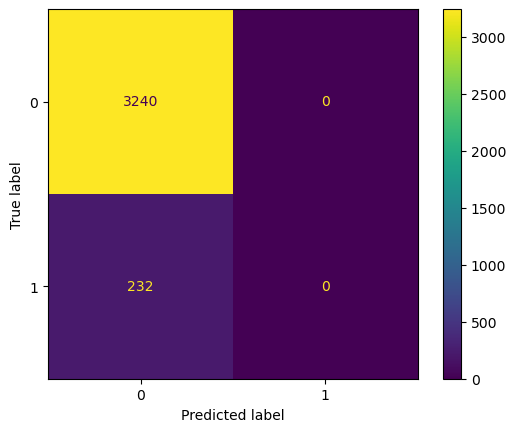

In [61]:
# Compute confusion matrix values
cm = confusion_matrix(y_test_encoded, y_pred)

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot confusion matrix
disp.plot()

# Display plot
plt.show()

Create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the logistic regression model.

In [62]:
# Create classification report
report = classification_report(y_test_encoded, y_pred)

# Display classification report
print(report)

              precision    recall  f1-score   support

           0       0.93      1.00      0.97      3240
           1       0.00      0.00      0.00       232

    accuracy                           0.93      3472
   macro avg       0.47      0.50      0.48      3472
weighted avg       0.87      0.93      0.90      3472



/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### **Task 4c. Interpret model coefficients**

In [63]:
# Get feature names and model coefficients
feature_names = X_train_final.columns
coefficients = log_reg.coef_[0]

# Create dataframe for readability
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Display coefficients dataframe
coef_df


,Feature,Coefficient
0,video_duration_sec,-0.004490
1,video_view_count,-0.000001
2,video_like_count,-0.000002
3,video_share_count,0.000007
4,video_download_count,-0.000076
5,video_comment_count,0.000168
6,text_length,-0.011682
7,video_duration_sec,-0.004490
8,video_view_count,-0.000001
9,video_like_count,-0.000002


### **Task 4d. Conclusion**

1. What are the key takeaways from this project?

2. What results can be presented from this project?

1.The project showed that engagement metrics and verification status are important predictors in classifying TikTok content. Logistic regression successfully identified patterns related to user behavior and video performance.
2.The model achieved measurable classification performance and identified key variables such as video views, likes, shares, and verification status as strong predictors of content classification.


**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged. 